# ☕ Aurora Coffee Co. — A Causal MMM Story

> **A six-notebook tour of `mmm_framework`, told through one company's quarterly budget decision.**

**Aurora Coffee Co.** is a fast-growing direct-to-consumer coffee brand with two product lines —
**Original** (ground & whole bean) and **Cold Brew** (ready-to-drink) — and four paid media channels:
**TV, Search, Social, Display**.

It's planning season. The CMO has to defend the marketing budget to the CFO and decide where next
quarter's dollars go. The data science team is asked one deceptively simple question:

> ### *"What is each channel actually worth — and how should we reallocate?"*

A normal dashboard answers this with **correlations**. This notebook set shows why that answer is
*wrong in a way that costs real money*, and how a **causal** marketing-mix model — with honest
uncertainty, experiment calibration, and mediation — gets it right.

| Chapter | Notebook | The question |
|---|---|---|
| **0** | *this one* | What's the trap? |
| **1 · Causality** | `01_causality.ipynb` | Can we trust the number? |
| **2 · Base MMM** | `02_base_mmm.ipynb` | What is each channel worth? |
| **3 · Extended MMM** | `03_extended_mmm.ipynb` | What is TV *really* doing? And do our products fight each other? |
| **4 · Reporting** | `04_reporting.ipynb` | How do we put this in front of the board? |
| **5 · The workflow** | `05_unified_workflow.ipynb` | Put it all together → a defensible plan. |

*Everything runs on synthetic data (`aurora.py`) built with a known ground truth, so we can grade the
model against the real answer. Fits use small draw counts to stay fast — bump them up for real work.*

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
from loguru import logger
logger.remove(); logger.add(sys.stderr, level="ERROR")   # quiet framework logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aurora import generate_aurora, CHANNELS, PRODUCTS, PALETTE, CHANNEL_COLORS

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

aurora = generate_aurora()      # the one dataset every chapter shares

## Meet the business

Two years of weekly data: revenue (in \$000s), spend by channel, and a few business drivers.

In [2]:
df = aurora.frame()
print(f"{len(df)} weeks · revenue ${aurora.sales_total.mean():,.0f}k/wk avg · "
      f"media is {100*aurora.true_contribution.sum()/aurora.sales_total.sum():.0f}% of revenue")
df[["TV","Search","Social","Display","sales_total"]].head()

104 weeks · revenue $839k/wk avg · media is 26% of revenue


,TV,Search,Social,Display,sales_total
week,,,,,
2023-01-02,67.999199,38.205978,31.232869,24.212585,752.852957
2023-01-09,62.856302,38.448640,32.006170,23.259357,787.080749
2023-01-16,64.646370,38.958597,35.164851,23.354630,784.080768
2023-01-23,65.612334,30.608775,30.809131,22.923933,784.252845
2023-01-30,65.712088,30.787726,32.859519,24.545055,801.442814


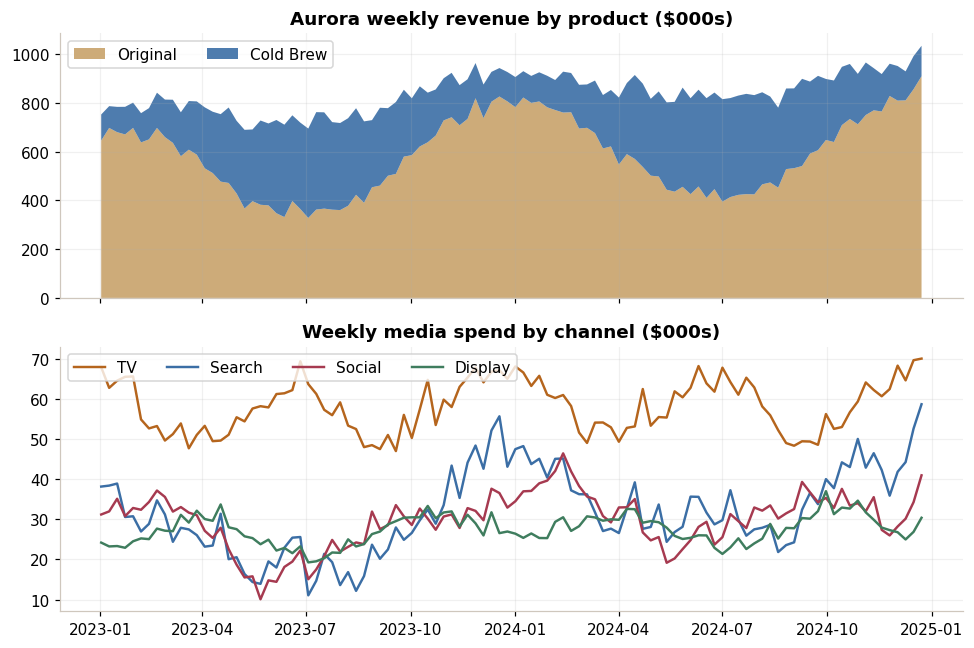

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.stackplot(df.index, aurora.sales_original, aurora.sales_coldbrew,
              labels=PRODUCTS, colors=[PALETTE["crema"], PALETTE["sky"]], alpha=.9)
ax1.set_title("Aurora weekly revenue by product ($000s)"); ax1.legend(loc="upper left", ncol=2)
for ch in CHANNELS:
    ax2.plot(df.index, df[ch], color=CHANNEL_COLORS[ch], lw=1.6, label=ch)
ax2.set_title("Weekly media spend by channel ($000s)"); ax2.legend(ncol=4, loc="upper left")
plt.tight_layout(); plt.show()

## The trap 🪤

The fastest way to "value" a channel is to correlate its spend with sales. Let's do exactly that —
and put it next to the **true** ROAS (which we know, because we built this world).

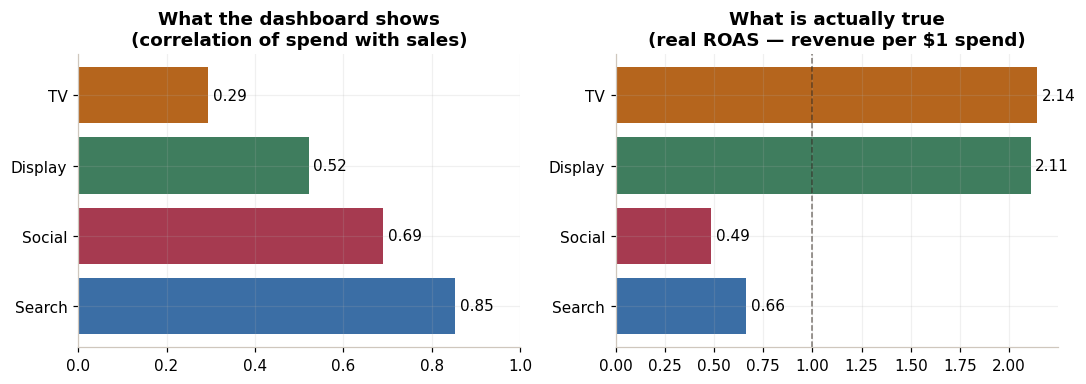

In [4]:
naive_corr = {c: np.corrcoef(aurora.spend[c], aurora.sales_total)[0, 1] for c in CHANNELS}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 3.6))
order = ["Search", "Social", "Display", "TV"]
axL.barh(order, [naive_corr[c] for c in order], color=[CHANNEL_COLORS[c] for c in order])
axL.set_title("What the dashboard shows\n(correlation of spend with sales)"); axL.set_xlim(0, 1)
axR.barh(order, [aurora.true_roas[c] for c in order], color=[CHANNEL_COLORS[c] for c in order])
axR.axvline(1.0, color=INK, ls="--", lw=1, alpha=.6)
axR.set_title("What is actually true\n(real ROAS — revenue per $1 spend)")
for ax in (axL, axR): ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.tight_layout(); plt.show()

Look at the disagreement:

- **Search** has the *strongest* correlation with sales (≈0.85) — the dashboard's hero. Its **true ROAS
  is 0.66**: it loses money.
- **TV** has a *weak* correlation (≈0.29) — the dashboard's first cut. Its **true ROAS is 2.1**: it's the
  best investment Aurora has.

Acting on the left chart, Aurora would **pour money into Search and starve TV** — exactly backwards.
Three things are breaking the correlation:

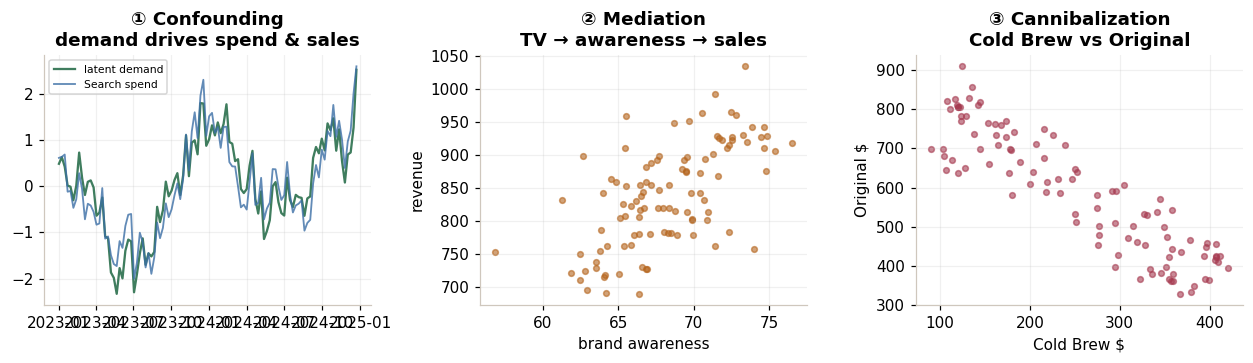

In [5]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(11.5, 3.4))

# 1) Confounding: a latent "demand" drives BOTH Search spend AND sales.
a1.plot(df.index, (aurora.demand-aurora.demand.mean())/aurora.demand.std(), color=PALETTE["leaf"], label="latent demand")
a1.plot(df.index, (aurora.spend["Search"]-aurora.spend["Search"].mean())/aurora.spend["Search"].std(),
        color=CHANNEL_COLORS["Search"], lw=1.2, alpha=.8, label="Search spend")
a1.set_title("① Confounding\ndemand drives spend & sales"); a1.legend(fontsize=7, loc="upper left")

# 2) Mediation: TV builds awareness, awareness drives sales.
a2.scatter(aurora.awareness, aurora.sales_total, s=14, color=CHANNEL_COLORS["TV"], alpha=.6)
a2.set_title("② Mediation\nTV → awareness → sales"); a2.set_xlabel("brand awareness"); a2.set_ylabel("revenue")

# 3) Cannibalization: the two products fight.
a3.scatter(aurora.sales_coldbrew, aurora.sales_original, s=14, color=PALETTE["berry"], alpha=.6)
a3.set_title("③ Cannibalization\nCold Brew vs Original"); a3.set_xlabel("Cold Brew $"); a3.set_ylabel("Original $")
plt.tight_layout(); plt.show()

1. **Confounding** — Aurora bids harder on Search/Social *when demand is already high*, so their spend
   rides the same wave as sales. The credit belongs to demand, not the channel.
2. **Mediation** — TV barely sells anything *directly*; it builds **awareness**, and awareness sells.
   Its value is real but hidden one step upstream.
3. **Cannibalization** — Cold Brew and Original eat each other's lunch in summer.

A correlation can't see past any of these. The rest of this set fixes each one — and ends with a
**reallocation that's worth real money**. Start with **`01_causality.ipynb`**.